In [16]:
import pandas as pd

df_raw = pd.read_csv('/Users/oseli/Desktop/FOM/conference/summer_conference/open/ChEMBL_ASK1(IC50).csv', delimiter=';')

# 컬럼명 확인 (정상적으로 읽혔는지)
print(df_raw.columns)

# 'Standard Relation' 컬럼에서 '=' 개수 세기
count_equals = (df_raw['Standard Relation'] == "'='").sum()
print(count_equals)


Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

In [4]:
# Jupyter Notebook: 분자 분석 및 시각화 파이프라인

# ======================
# 셀 1: 라이브러리 임포트
# ======================

import os
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, rdFMCS
from rdkit.DataStructs import TanimotoSimilarity

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA

# 시각화 스타일 설정
sns.set_style('whitegrid')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# ======================
# 헬퍼 함수: 유사도 히트맵 및 PCA 시각화
# ======================
def plot_heatmap(sim_matrix, ids, title, threshold=None, method='single'):
    """유사도 행렬에 대해 클러스터링 히트맵과 덴드로그램을 그립니다."""
    dist = 1.0 - sim_matrix
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method=method)

    sns.clustermap(
        pd.DataFrame(sim_matrix, index=ids, columns=ids),
        row_linkage=Z, col_linkage=Z,
        cmap='vlag', figsize=(10,10)
    )
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.show()

    if threshold is not None:
        plt.figure(figsize=(12,4))
        dendrogram(Z, no_labels=True)
        plt.axhline(y=threshold, color='red', linestyle='--')
        plt.title(f"Dendrogram (threshold={threshold})", fontsize=12)
        plt.xlabel('Distance')
        plt.ylabel('Cluster')
        plt.show()

        clusters = fcluster(Z, t=threshold, criterion='distance')
        counts = pd.Series(clusters).value_counts()
        print("Clusters (size > 5):")
        print(counts[counts > 5])


def plot_pca(sim_matrix, ids, inhibition, cmap='viridis', title='PCA on Similarity'):
    """유사도 행렬 기반 PCA 결과를 2D 산점도로 시각화합니다."""
    # PCA import가 셀 상단에 있어야 인식됩니다.
    pcs = PCA(n_components=2).fit_transform(sim_matrix)
    df_pca = pd.DataFrame(pcs, index=ids, columns=['PC1','PC2'])
    df_pca['Inhibition'] = inhibition

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df_pca, x='PC1', y='PC2',
        hue='Inhibition', palette=cmap,
        edgecolor='none'
    )
    plt.title(title, fontsize=14)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='Inhibition', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()

# MCS 유사도 계산 함수
def compute_mcs_similarity(mols):
    """리스트된 Mol 객체들 간 MCS 기반 Tanimoto 유사도 매트릭스를 계산합니다."""
    n = len(mols)
    sim = np.eye(n)
    for i in range(n-1):
        for j in range(i+1, n):
            res = rdFMCS.FindMCS([mols[i], mols[j]])
            na = res.numAtoms
            a1 = mols[i].GetNumAtoms(); a2 = mols[j].GetNumAtoms()
            sim_val = na / (a1 + a2 - na) if (a1 + a2 - na) > 0 else 0
            sim[i,j] = sim[j,i] = sim_val
    return sim

In [5]:
# ======================
# 셀 2: 데이터 로드 및 전처리
# ======================

# 파일 경로 직접 지정 (필요 시 수정)
file_path = "/Users/oseli/Desktop/FOM/conference/summer_conference/open/ChEMBL_ASK1(IC50)_clean.csv"

# 1) CSV 파일 읽기: 인코딩 cp1252 사용 (에러 방지용)
df_raw = pd.read_csv(file_path, encoding="cp1252")
print(f"데이터 로드: {df_raw.shape[0]}행, {df_raw.shape[1]}열")

# 2) SMILES 문자열을 Mol 객체로 변환
df_raw['mol'] = df_raw['SMILES'].map(Chem.MolFromSmiles)

# 3) 변환 실패(SMILES 파싱 실패) 건수 출력
invalid = df_raw['mol'].isna().sum()
print(f"파싱 실패 SMILES 수: {invalid}건")

# 4) 유효한 Mol만 남기고 인덱스 재설정
df = df_raw.dropna(subset=['mol']).reset_index(drop=True)
print(f"유효한 분자 수: {df.shape[0]}행\n")


데이터 로드: 824행, 5열
파싱 실패 SMILES 수: 0건
유효한 분자 수: 824행



In [8]:
# ======================
# standard type 유형 확인
# ======================
# Standard Type 값 개수 집계
type_counts = df['Standard Type'].value_counts(dropna=False)

# 결과 출력
print("🔍 'Standard Type' 열의 고유값 개수:")
print(type_counts)

# IC50 vs 그 외
ic50_count = type_counts.get('IC50', 0)
other_count = type_counts.sum() - ic50_count

print(f"\n✅ IC50 개수: {ic50_count}")
print(f"✅ 다른 타입 개수: {other_count}")

🔍 'Standard Type' 열의 고유값 개수:
Standard Type
IC50    824
Name: count, dtype: int64

✅ IC50 개수: 824
✅ 다른 타입 개수: 0


In [5]:
from rdkit.Chem import Descriptors, rdMolDescriptors

def featurize_full(mol):
    """단일 분자에 대한 통합 피처 계산"""
    feats = {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'NumValenceElectrons': Descriptors.NumValenceElectrons(mol),
        'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
        'NumAliphaticRings': Descriptors.NumAliphaticRings(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'NumRings': rdMolDescriptors.CalcNumRings(mol),
        'NumCharges': sum(a.GetFormalCharge() != 0 for a in mol.GetAtoms()),
        'NumCarbonAtoms': sum(a.GetSymbol() == 'C' for a in mol.GetAtoms())
    }

    # 주요 원소 개수
    atom_types = ['C', 'H', 'N', 'O', 'Cl', 'S', 'F', 'Br', 'I', 'B', 'Si']
    for atom in atom_types:
        feats[f'Num_{atom}'] = sum(a.GetSymbol() == atom for a in mol.GetAtoms())

    # 기능성 그룹 SMARTS 패턴
    fg_smarts = {
        'Amine_primary': '[NX3;H2]',
        'Amine_secondary': '[NX3;H1]',
        'Amine_tertiary': '[NX3;H0]',
        'Alcohol': '[OX2H]',
        'Aldehyde': '[CX3H1](=O)[#6]',
        'Ketone': '[#6][CX3](=O)[#6]',
        'Carboxylic_acid': '[CX3](=O)[OX2H1]',
        'Ester': '[CX3](=O)[OX2][#6]',
        'Nitrile': '[CX2]#N'
    }
    for name, patt in fg_smarts.items():
        smarts = Chem.MolFromSmarts(patt)
        feats[f'FG_{name}'] = len(mol.GetSubstructMatches(smarts))

    return feats

# 피처 추출 및 병합
full_feats = [featurize_full(mol) for mol in df['mol']]
full_feat_df = pd.DataFrame(full_feats)

# 결과 통합: SMILES, pIC50, 피처
df_features = pd.concat([df[['Smiles', 'pIC50']], full_feat_df], axis=1)

# 결과 확인
print(df_features.head())
print(f"전체 피처 매트릭스 크기: {df_features.shape}")


                                              Smiles     pIC50    MolWt  \
0   Cn1cc(Cl)c2cnc(NC(=O)c3ccc([C@](C)(O)CO)cc3)cc21  7.420216  359.813   
1         Cc1cc2c(-c3ccc(S(=O)(=O)NCCN)s3)ccnc2[nH]1  6.600326  336.442   
2  Cc1cc(C)c2nc(N3C(=O)C(O)=C(C(=O)c4ccc(Cl)cc4)C...  5.200659  517.050   
3  Cc1ccc(C(=O)C2=C(O)C(=O)N(c3nc4ccc(F)cc4s3)C2c...  5.119186  500.595   
4  CCOc1ccc2nc(N3C(=O)C(O)=C(C(=O)c4ccccc4)C3c3cc...  5.376751  490.968   

   MolLogP    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  \
0  2.67880   87.38           3              5                  4   
1  1.83682  100.87           3              5                  5   
2  7.47284   70.50           1              5                  5   
3  6.82422   70.50           1              5                  4   
4  6.13130   79.73           1              6                  6   

   NumValenceElectrons  HeavyAtomCount  ...  Num_Si  FG_Amine_primary  \
0                  130              25  ...       0                

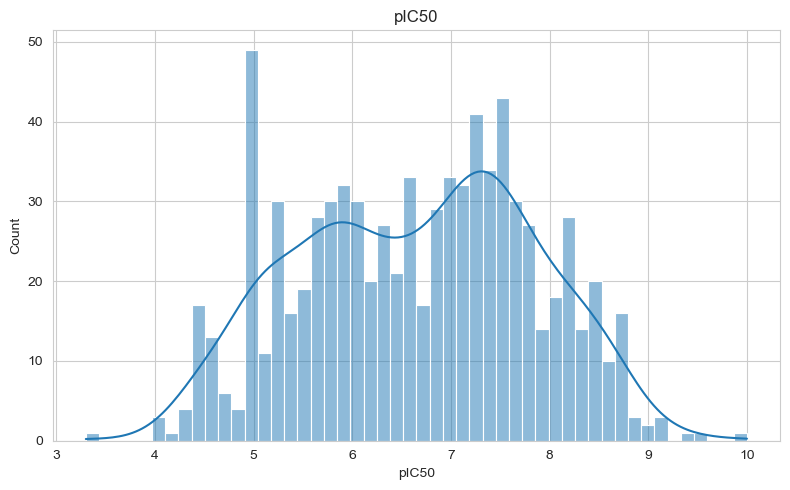

In [6]:
# ======================
# 셀 4a: EDA - pIC50
# ======================
plt.figure(figsize=(8,5))
sns.histplot(df_raw['pIC50'], bins=50, kde=True)
plt.title('pIC50')
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
# ======================
# 셀 4b: EDA - 원자 개수 분포 박스플롯
# ======================
atom_types=['C','H','N','O','Cl','S','F','Br','I','B','Si']
plt.figure(figsize=(10,5))
sns.boxplot(data=df_features[atom_types])
plt.title('Atom Count Distribution')
plt.xlabel('Atom Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['C', 'H', 'N', 'O', 'Cl', 'S', 'F', 'Br', 'I', 'B', 'Si'], dtype='object')] are in the [columns]"

<Figure size 1000x500 with 0 Axes>

In [ ]:
# ======================
#  Morgan 지문 생성
# ======================
def get_morgan_fp(mol, radius=2, nBits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

fps_morgan=[get_morgan_fp(m) for m in df['mol']]
print(f"Morgan fingerprints: {len(fps_morgan)}개, 길이={fps_morgan[0].GetNumBits()}")
fps_array=np.array([list(fp) for fp in fps_morgan])

# 첫 5개의 지문 출력 (각 지문은 2048 비트 벡터)
for i in range(5):
    print(f"\n[Molecule {i+1}]")
    print(fps_array[i])

# 또는 DataFrame으로 보기 좋게 출력 (선택)
fps_df = pd.DataFrame(fps_array[:5])
print("\n▶️ 지문 (앞 5개):")
display(fps_df)


[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerator
[20:15:50] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprints: 824개, 길이=2048

[Molecule 1]
[0 0 0 ... 0 0 0]

[Molecule 2]
[0 0 0 ... 0 0 1]

[Molecule 3]
[0 1 0 ... 0 0 0]

[Molecule 4]
[0 0 0 ... 0 0 0]

[Molecule 5]
[0 0 0 ... 0 0 0]

▶️ 지문 (앞 5개):


,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_87789/165785223.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/oseli/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


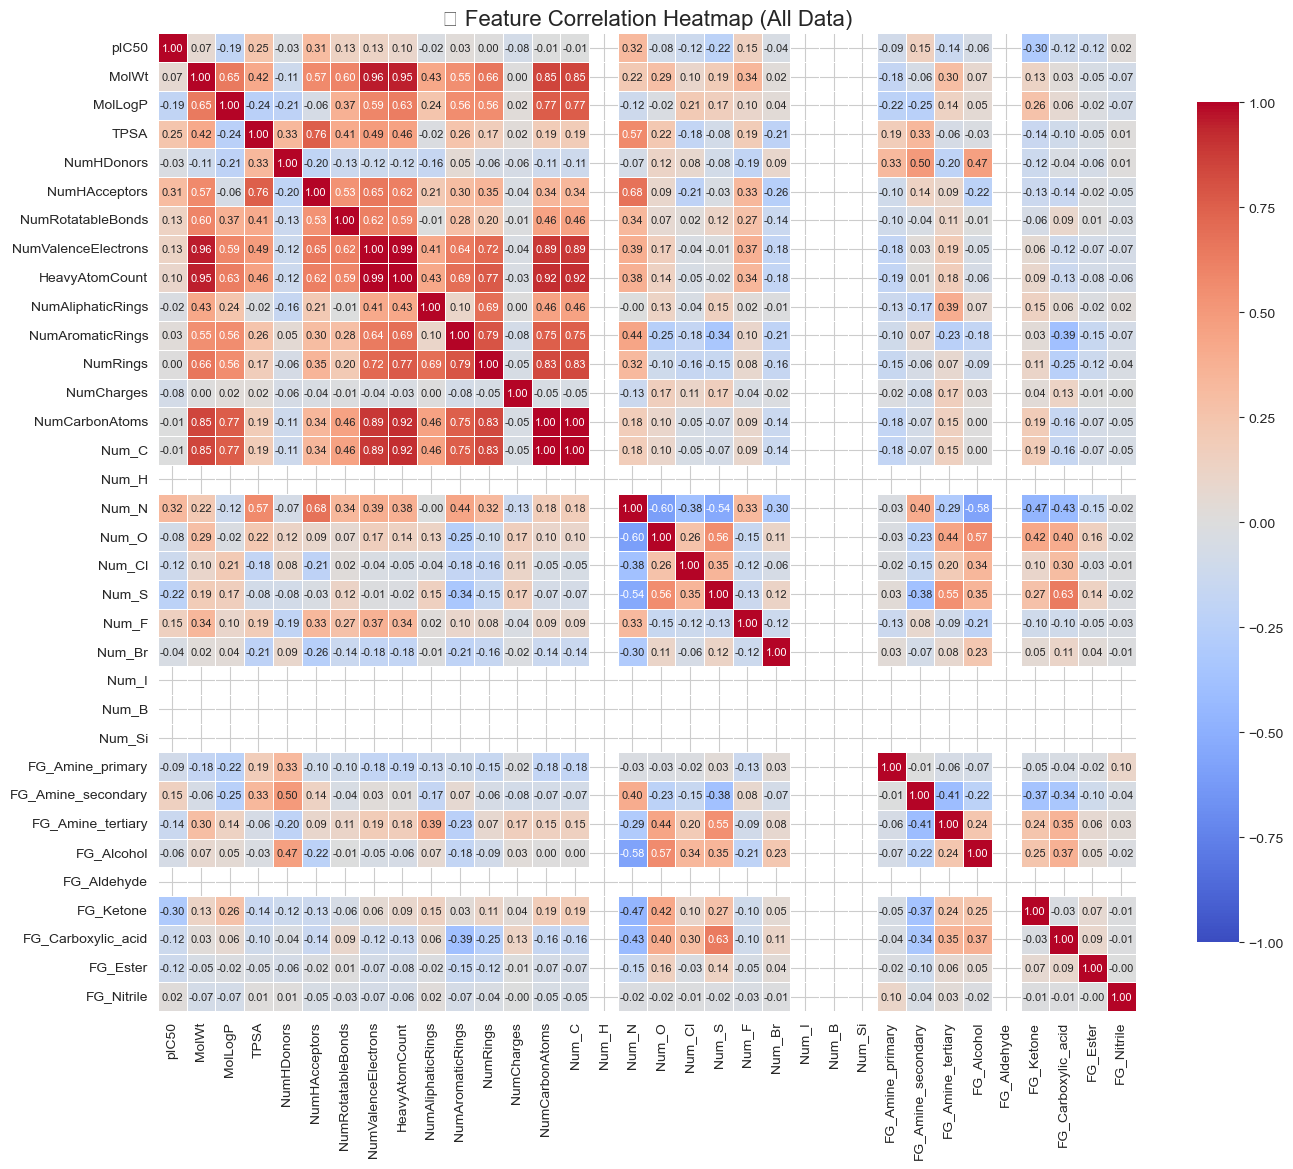

/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_87789/165785223.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_pX.values, y=corr_with_pX.index, palette='coolwarm')
/var/folders/2q/v_79vqld72sf48ghq2z01j2m0000gn/T/ipykernel_87789/165785223.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/oseli/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


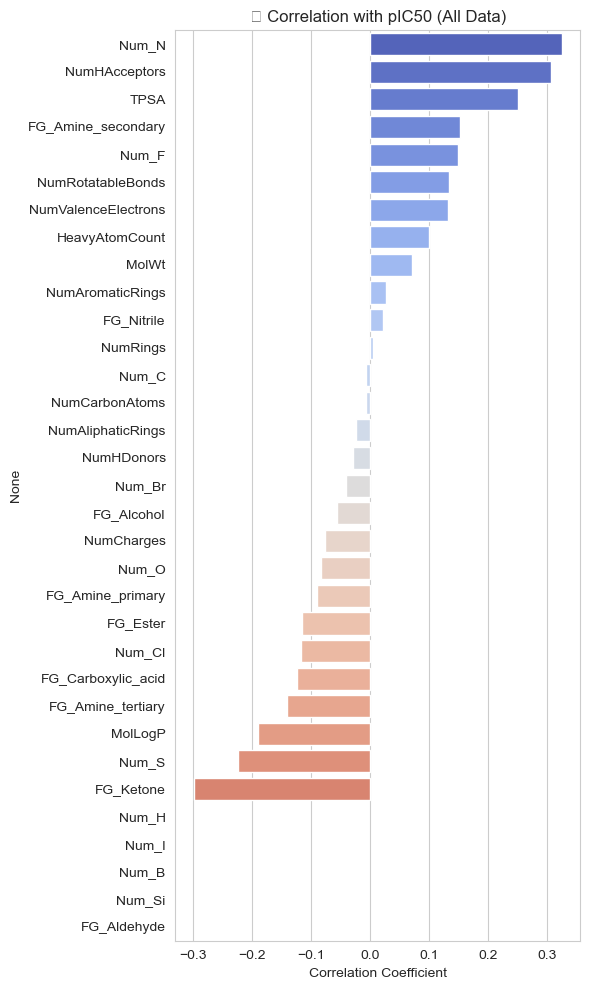

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 수치형 컬럼만 선택
numeric_cols = df_features.select_dtypes(include=[np.number])

# 상관 행렬 계산
corr_matrix = numeric_cols.corr()

# pIC50가 포함되어 있는지 확인
if 'pIC50' not in corr_matrix.columns:
    raise ValueError("❌ 'pIC50' 컬럼이 상관 행렬에 없습니다. 컬럼명을 확인하세요.")

# pIC50와의 상관계수만 추출 (자기 자신 제외)
corr_with_pX = corr_matrix['pIC50'].drop(labels=['pIC50']).sort_values(ascending=False)

# 히트맵
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})

plt.title("📊 Feature Correlation Heatmap (All Data)", fontsize=16)
plt.tight_layout()
plt.show()
# 바 차트
plt.figure(figsize=(6, 10))
sns.barplot(x=corr_with_pX.values, y=corr_with_pX.index, palette='coolwarm')
plt.title("📈 Correlation with pIC50 (All Data)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


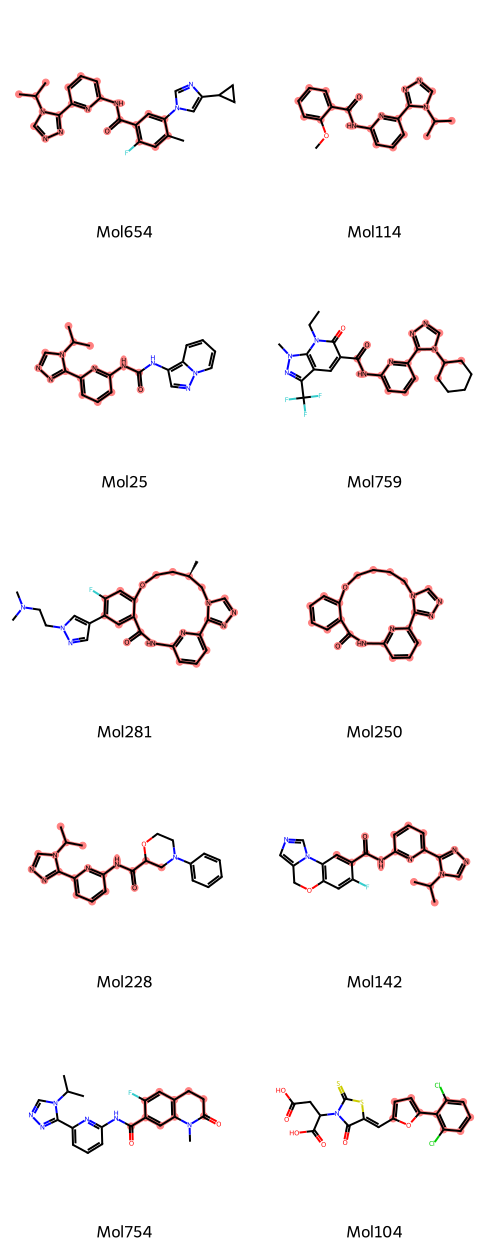

In [ ]:
# ======================
# 셀 7: MCS 샘플링 및 시각화
# ======================
random.seed(42)
pairs=[tuple(random.sample(range(len(df)),2)) for _ in range(5)]

mols,highlights,legends=[],[],[]
for i,j in pairs:
    m1,m2=df.loc[i,'mol'],df.loc[j,'mol']
    res=rdFMCS.FindMCS([m1,m2])
    mcs_mol=Chem.MolFromSmarts(res.smartsString)
    match1=m1.GetSubstructMatch(mcs_mol)
    match2=m2.GetSubstructMatch(mcs_mol)
    mols+=[m1,m2]
    highlights+=[list(match1),list(match2)]
    legends+=[f"Mol{i}",f"Mol{j}"]

from rdkit.Chem.Draw import MolsToGridImage
img=MolsToGridImage(mols,highlightAtomLists=highlights,molsPerRow=2,subImgSize=(250,250),legends=legends)
display(img)

In [ ]:
# ======================
# 셀 8: MCS 기반 유사도 클러스터링 & 히트맵
# ======================
# mol_list 전체 데이터 Mol 객체 리스트로 설정
mol_list = df['mol']
ids = df.index.astype(str).tolist()  # 전체 인덱스를 문자열 ID로 사용

print("🔄 MCS 유사도 행렬을 전체 데이터로 새로 계산 중...")
sim_mcs = compute_mcs_similarity(mol_list)

# 결과 저장 (선택적으로 저장)
mcs_npy = 'fmcs_tanimoto_full_new.npy'
mcs_csv = 'fmcs_tanimoto_full_new.csv'
np.save(mcs_npy, sim_mcs)
pd.DataFrame(sim_mcs, index=ids, columns=ids).to_csv(mcs_csv)

# 히트맵 시각화
plot_heatmap(sim_mcs, ids, title='🔬 MCS-based Tanimoto Similarity (full dataset)', threshold=0.34)
